# Netflix Content Analysis: Exploratory Analysis
**Goal:** understand what Netflix offers and how its catalogue has changed.

**Questions**
1. How fast did the catalogue grow, and is the mix shifting from movies to TV shows?
2. Which genres dominate?
3. Which countries produce the most content, and what kind?
4. Who is the content for (audience ratings)?
5. How long are movies, and how many seasons do TV shows run?
6. How quickly does content reach Netflix after release?

**Note:** the data runs to **September 2021**, so 2021 is a partial year.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('../data/processed/netflix_clean.csv')
genres = pd.read_csv('../data/processed/netflix_genres.csv')
countries = pd.read_csv('../data/processed/netflix_countries.csv')
movies = df[df['type'] == 'Movie']
shows = df[df['type'] == 'TV Show']
print(df.shape, movies.shape, shows.shape)

(8807, 25) (6131, 25) (2676, 25)


### Chart style
Movies are always blue and TV shows always orange, so colours mean the same thing in every chart.

In [2]:
MOVIE, TV, GREY = '#2a78d6', '#eb6834', '#b9b8b2'
TEXT, MUTED = '#0b0b0b', '#52514e'
plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#d6d5d0', 'axes.grid': True, 'grid.color': '#ecebe7',
    'axes.axisbelow': True, 'font.size': 10, 'axes.titlesize': 12,
    'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': TEXT, 'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight'})

def save(fig, name):
    fig.savefig(f'../images/{name}.png')
    plt.show()

## 1. Catalogue growth and the movie / TV mix

In [3]:
df['type'].value_counts().to_frame().assign(share=lambda x: (x['count'] / x['count'].sum()).round(3))

,count,share
type,,
Movie,6131,0.696
TV Show,2676,0.304


In [4]:
added = (df.dropna(subset=['year_added'])
           .pivot_table(index='year_added', columns='type', values='show_id', aggfunc='count')
           .fillna(0).astype(int))
added.index = added.index.astype(int)
added.loc[2014:]

type,Movie,TV Show
year_added,,
2014,19,5
2015,56,26
2016,253,176
2017,839,349
2018,1237,412
2019,1424,592
2020,1284,595
2021,993,505


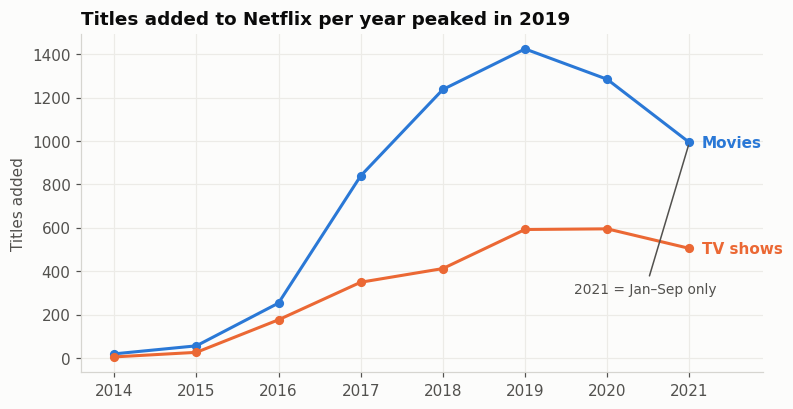

In [5]:
a = added.loc[2014:]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(a.index, a['Movie'], color=MOVIE, linewidth=2, marker='o', markersize=5)
ax.plot(a.index, a['TV Show'], color=TV, linewidth=2, marker='o', markersize=5)
ax.text(a.index[-1] + 0.15, a['Movie'].iloc[-1], 'Movies', color=MOVIE, va='center', fontweight='bold')
ax.text(a.index[-1] + 0.15, a['TV Show'].iloc[-1], 'TV shows', color=TV, va='center', fontweight='bold')
ax.annotate('2021 = Jan–Sep only', xy=(2021, a.loc[2021, 'Movie']), xytext=(2019.6, 300),
            color=MUTED, fontsize=9, arrowprops=dict(arrowstyle='-', color=MUTED))
ax.set_xlim(2013.6, 2021.9)
ax.set_title('Titles added to Netflix per year peaked in 2019')
ax.set_ylabel('Titles added')
save(fig, '01_titles_added_per_year')

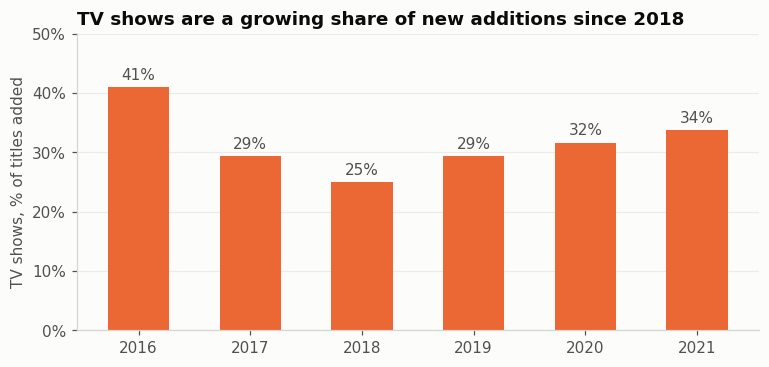

In [6]:
tv_share = (added['TV Show'] / added.sum(axis=1)).loc[2016:]
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(tv_share.index, tv_share.values, color=TV, width=0.55)
ax.bar_label(bars, labels=[f'{v:.0%}' for v in tv_share.values], padding=3, color=MUTED)
ax.set_ylim(0, 0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_title('TV shows are a growing share of new additions since 2018')
ax.set_ylabel('TV shows, % of titles added')
ax.grid(axis='x', visible=False)
save(fig, '02_tv_share_of_additions')

**Finding 1:** the catalogue is **70% movies and 30% TV shows**. Additions grew from 82 titles in 2015 to a peak of **2,016 in 2019**, then slowed in 2020.

**Finding 2:** since 2018, TV shows have taken a growing share of new additions, rising from **25% to 34%** in 2021. Netflix is shifting towards series, which keep subscribers watching for longer.

## 2. Genres
A title can have up to three genres, so counts use the genre table (one row per title per genre).

In [7]:
top_genres = genres['genre'].value_counts().head(12)
top_genres

genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Name: count, dtype: int64

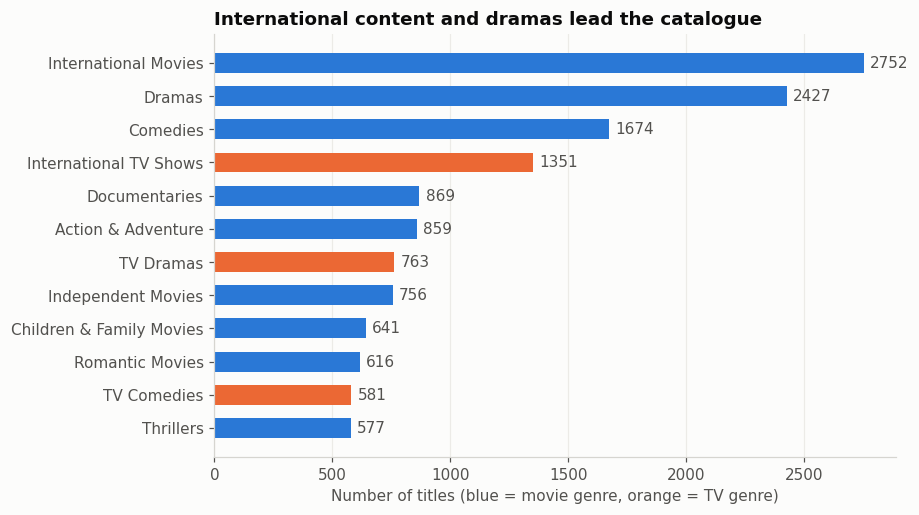

In [8]:
s = top_genres[::-1]
colors = [TV if 'TV' in g or 'Series' in g or 'Docuseries' in g else MOVIE for g in s.index]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(s.index, s.values, color=colors, height=0.6)
ax.bar_label(bars, padding=4, color=MUTED)
ax.set_title('International content and dramas lead the catalogue')
ax.set_xlabel('Number of titles (blue = movie genre, orange = TV genre)')
ax.grid(axis='y', visible=False)
save(fig, '03_top_genres')

In [9]:
for t in ['Movie', 'TV Show']:
    print(t, genres[genres['type'] == t]['genre'].value_counts().head(5).to_dict())

Movie {'International Movies': 2752, 'Dramas': 2427, 'Comedies': 1674, 'Documentaries': 869, 'Action & Adventure': 859}
TV Show {'International TV Shows': 1351, 'TV Dramas': 763, 'TV Comedies': 581, 'Crime TV Shows': 470, "Kids' TV": 451}


**Finding 3:** "International Movies" (2,752 titles) is the largest genre, followed by Dramas (2,427) and Comedies (1,674). For TV, International TV Shows lead, then TV Dramas and TV Comedies. Netflix leans heavily on non-US content.

## 3. Countries
Titles with an unknown country are excluded here.

In [10]:
known = countries[countries['country_name'] != 'Unknown']
by_country = (known.pivot_table(index='country_name', columns='type', values='show_id', aggfunc='count').fillna(0))
by_country['total'] = by_country.sum(axis=1)
by_country['tv_share'] = by_country['TV Show'] / by_country['total']
top10 = by_country.sort_values('total', ascending=False).head(10)
top10.astype({'Movie': int, 'TV Show': int, 'total': int}).round({'tv_share': 2})

type,Movie,TV Show,total,tv_share
country_name,,,,
United States,2752,938,3690,0.25
India,962,84,1046,0.08
United Kingdom,534,272,806,0.34
Canada,319,126,445,0.28
France,303,90,393,0.23
Japan,119,199,318,0.63
Spain,171,61,232,0.26
South Korea,61,170,231,0.74
Germany,182,44,226,0.19


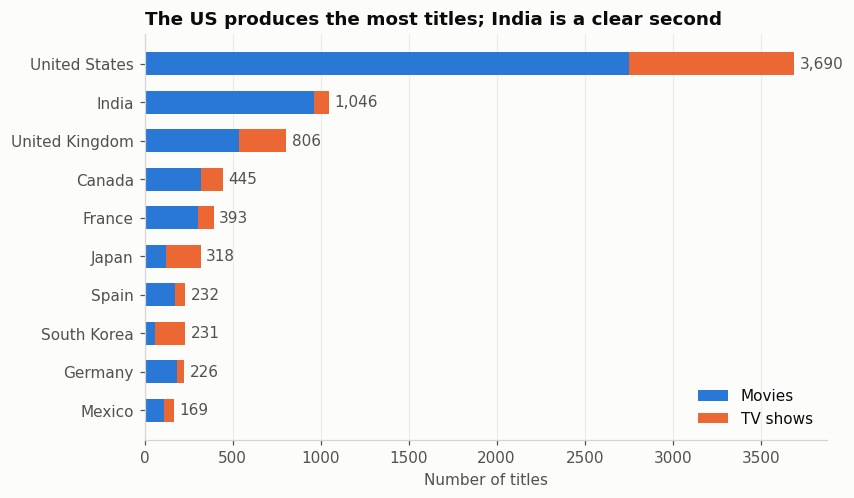

In [11]:
t = top10.sort_values('total')
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(t.index, t['Movie'], color=MOVIE, height=0.6, label='Movies')
ax.barh(t.index, t['TV Show'], left=t['Movie'], color=TV, height=0.6, label='TV shows')
for i, total in enumerate(t['total']):
    ax.text(total + 30, i, f'{int(total):,}', va='center', color=MUTED)
ax.legend(frameon=False, loc='lower right')
ax.set_title('The US produces the most titles; India is a clear second')
ax.set_xlabel('Number of titles')
ax.grid(axis='y', visible=False)
save(fig, '04_top_countries')

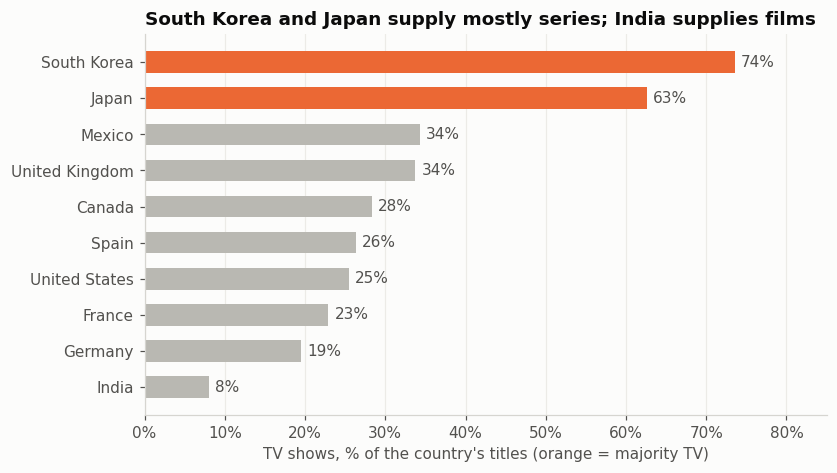

In [12]:
s = top10['tv_share'].sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [TV if v >= 0.5 else GREY for v in s.values]
bars = ax.barh(s.index, s.values, color=colors, height=0.6)
ax.bar_label(bars, labels=[f'{v:.0%}' for v in s.values], padding=4, color=MUTED)
ax.set_xlim(0, 0.85)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_title('South Korea and Japan supply mostly series; India supplies films')
ax.set_xlabel('TV shows, % of the country\'s titles (orange = majority TV)')
ax.grid(axis='y', visible=False)
save(fig, '05_tv_share_by_country')

**Finding 4:** the **United States** contributes 3,690 titles, followed by **India** (1,046) and the UK (806).

**Finding 5:** countries specialise. **92% of Indian titles are movies**, while **South Korea (74%) and Japan (63%) mostly supply TV shows**, driven by K-dramas and anime.

## 4. Audience

In [13]:
aud = pd.crosstab(df['type'], df['audience'], normalize='index')[['Kids', 'Older Kids', 'Teens', 'Adults']]
aud.round(3)

audience,Kids,Older Kids,Teens,Adults
type,,,,
Movie,0.072,0.135,0.313,0.467
TV Show,0.174,0.121,0.274,0.429


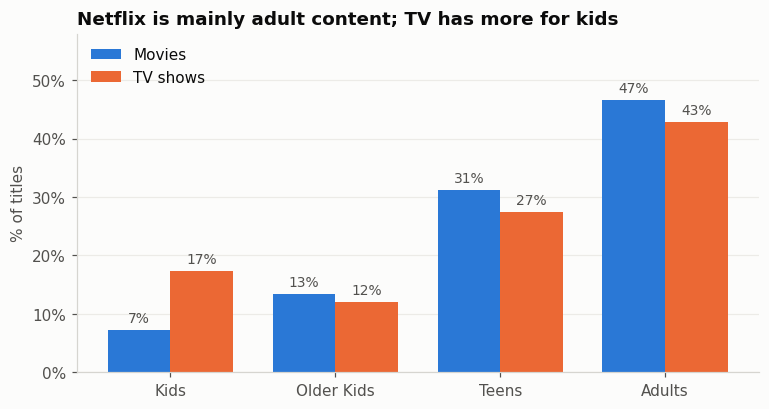

In [14]:
order = ['Kids', 'Older Kids', 'Teens', 'Adults']
x = np.arange(len(order)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - w/2, aud.loc['Movie', order], w, color=MOVIE, label='Movies')
b2 = ax.bar(x + w/2, aud.loc['TV Show', order], w, color=TV, label='TV shows')
for b in (b1, b2):
    ax.bar_label(b, labels=[f'{v:.0%}' for v in b.datavalues], padding=3, color=MUTED, fontsize=9)
ax.set_xticks(x, order)
ax.set_ylim(0, 0.58)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(frameon=False)
ax.set_title('Netflix is mainly adult content; TV has more for kids')
ax.set_ylabel('% of titles')
ax.grid(axis='x', visible=False)
save(fig, '06_audience_by_type')

In [15]:
df['rating'].value_counts().head(5)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

**Finding 6:** **46% of titles are for adults** (TV-MA is the most common rating, with 3,207 titles) and 30% for teens. Only **10% are for young kids**, but TV shows carry more kids' content (17%) than movies (7%).

## 5. Movie length and TV seasons

In [16]:
movies['movie_minutes'].describe().round(1)

count    6131.0
mean       99.6
std        28.3
min         3.0
25%        87.0
50%        98.0
75%       114.0
max       312.0
Name: movie_minutes, dtype: float64

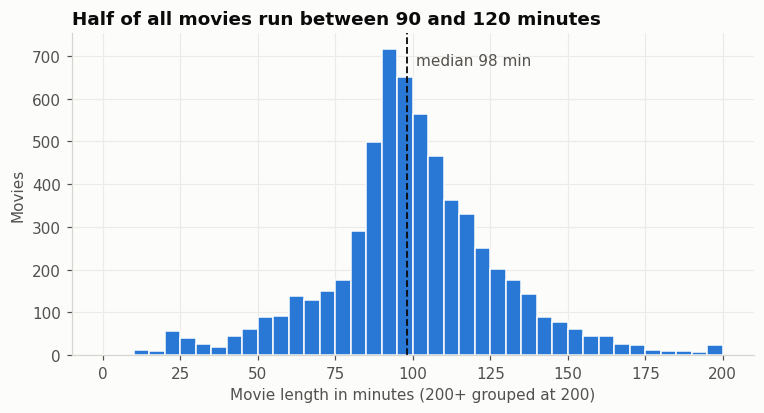

Share between 90 and 120 min: 0.513


In [17]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(movies['movie_minutes'].clip(upper=200), bins=np.arange(0, 205, 5), color=MOVIE, edgecolor='#fcfcfb')
med = movies['movie_minutes'].median()
ax.axvline(med, color=TEXT, linewidth=1.2, linestyle='--')
ax.text(med + 3, ax.get_ylim()[1] * 0.9, f'median {med:.0f} min', color=MUTED)
ax.set_title('Half of all movies run between 90 and 120 minutes')
ax.set_xlabel('Movie length in minutes (200+ grouped at 200)')
ax.set_ylabel('Movies')
save(fig, '07_movie_length')
print('Share between 90 and 120 min:', round(movies['movie_minutes'].between(90, 120).mean(), 3))

In [18]:
# Are newer movies shorter? Compare movies released before 2015 with 2015 onwards.
newer = movies.loc[movies['release_year'] >= 2015, 'movie_minutes']
older = movies.loc[movies['release_year'] < 2015, 'movie_minutes']
print('Median, 2015 onwards:', newer.median(), '| before 2015:', older.median())
# Mann-Whitney U test: movie lengths are skewed, so a rank-based test is safer than a t-test
stats.mannwhitneyu(newer, older)

Median, 2015 onwards: 96.0 | before 2015: 104.0


MannwhitneyuResult(statistic=np.float64(3218494.5), pvalue=np.float64(7.364687121967815e-55))

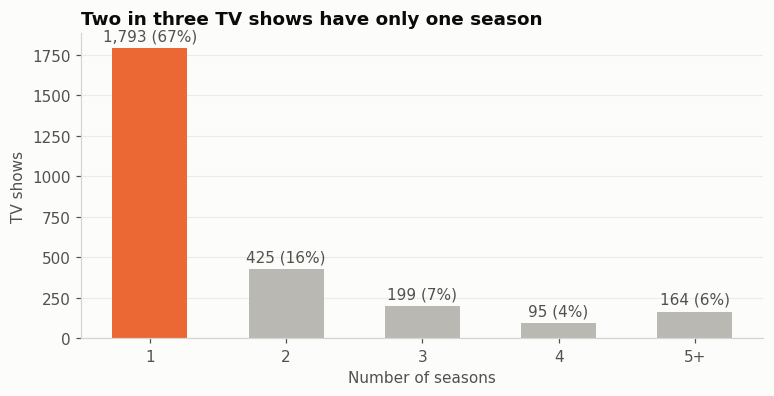

In [19]:
seasons = shows['tv_seasons'].clip(upper=5).value_counts().sort_index()
seasons.index = ['1', '2', '3', '4', '5+']
fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.bar(seasons.index, seasons.values, color=[TV] + [GREY] * 4, width=0.55)
ax.bar_label(bars, labels=[f'{v:,} ({v / seasons.sum():.0%})' for v in seasons.values], padding=3, color=MUTED)
ax.set_title('Two in three TV shows have only one season')
ax.set_xlabel('Number of seasons')
ax.set_ylabel('TV shows')
ax.grid(axis='x', visible=False)
save(fig, '08_tv_seasons')

**Finding 7:** the median movie runs **98 minutes**, and **51%** run between 90 and 120 minutes. Movies released from 2015 onwards are shorter (median 96 vs 104 minutes; Mann-Whitney U test, p < 0.001).

**Finding 8:** **67% of TV shows have only one season**. This reflects many limited series, newer shows, and series that were not renewed.

## 6. From release to Netflix

In [20]:
gap = df['years_to_netflix'].dropna()
print('Same year as release:', round((gap == 0).mean(), 3))
print('Within 1 year:', round((gap <= 1).mean(), 3))
gap.describe()

Same year as release: 0.369
Within 1 year: 0.549


count    8783.000000
mean        4.697825
std         8.790808
min         0.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: years_to_netflix, dtype: float64

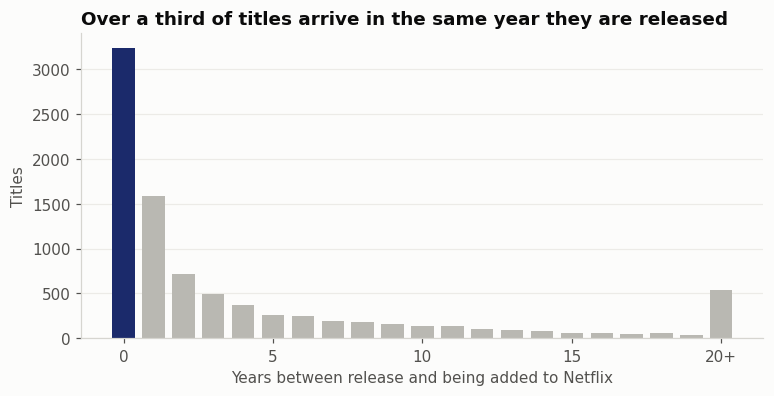

In [21]:
g = gap.clip(upper=20).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(g.index, g.values, color=['#1B2A6B' if i == 0 else GREY for i in g.index], width=0.75)
ax.set_xticks([0, 5, 10, 15, 20], ['0', '5', '10', '15', '20+'])
ax.set_title('Over a third of titles arrive in the same year they are released')
ax.set_xlabel('Years between release and being added to Netflix')
ax.set_ylabel('Titles')
ax.grid(axis='x', visible=False)
save(fig, '09_release_to_netflix_gap')

**Finding 9:** **37% of titles are added in the same year they are released**, and 55% within a year, consistent with Netflix's focus on new and original content. A long tail of older films (some decades old) fills out the library.

## Summary of findings
| # | Finding | Number |
|---|---|---|
| 1 | The catalogue is mostly movies | 70% movies, 30% TV shows |
| 2 | Additions peaked in 2019 | 82 (2015) → 2,016 (2019) |
| 3 | TV shows are a growing share of new additions | 25% (2018) → 34% (2021) |
| 4 | International content leads | International Movies: 2,752 titles |
| 5 | The US leads, India is second | 3,690 vs 1,046 titles |
| 6 | Countries specialise | India 92% movies; South Korea 74% TV |
| 7 | Mostly adult content | 46% adults, 10% young kids |
| 8 | Movies are getting shorter | median 96 min (2015+) vs 104 min (earlier) |
| 9 | Most TV shows end after one season | 67% have one season |
| 10 | Content arrives fast | 37% added in the release year |

**Limitations:** a snapshot to September 2021; country and director are missing for some titles; the data shows what is on Netflix, not what people watch.